In [1]:
import Xm

In [2]:
xm=Xm.Xm(XmlFile='../testdata/FW.XML')

=== LFKT ===

In [3]:
import pandas as pd

In [4]:
vLFKT=pd.merge(xm.dataFrames['LFKT'],xm.dataFrames['LFKT_ROWT'],left_on='pk',right_on='fk')

In [5]:
vLFKT.head(5)

,BESCHREIBUNG,INTPOL,NAME,ZEITOPTION,fkDE,pk_x,LF,ZEIT,fk,pk_y
0,Beschreibung Tabelle,0,LfTh,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700
1,Lastgang f(LFT),0,LFKT,0,5310335261658506550,5416134108033797245,1,0,5416134108033797245,5107407354706890507


In [6]:
vLFKT['ZEIT']=pd.to_numeric(vLFKT['ZEIT']) 

In [7]:
vLFKT['LF']=pd.to_numeric(vLFKT['LF']) 

In [8]:
vLFKT.head(5)

,BESCHREIBUNG,INTPOL,NAME,ZEITOPTION,fkDE,pk_x,LF,ZEIT,fk,pk_y
0,Beschreibung Tabelle,0,LfTh,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700
1,Lastgang f(LFT),0,LFKT,0,5310335261658506550,5416134108033797245,1,0,5416134108033797245,5107407354706890507


In [9]:
vLFKT['ZEIT_RANG']=vLFKT.groupby(['pk_x'])['ZEIT'].rank(ascending=True)

In [10]:
import numpy as np

In [11]:
vLFKT_gLF=vLFKT.groupby(['pk_x'], as_index=False).agg({'LF':[np.min,np.max]})

In [12]:
vLFKT_gLF.head(5)

pk_x   LF     
                       amin amax
0  4843828177877341965    1    1
1  5416134108033797245    1    1

In [13]:
vLFKT_gLF.columns= [tup[0]+tup[1] for tup in zip(vLFKT_gLF.columns.get_level_values(0),vLFKT_gLF.columns.get_level_values(1))]

In [14]:
vLFKT_gLF.head(5)

,pk_x,LFamin,LFamax
0,4843828177877341965,1,1
1,5416134108033797245,1,1


In [15]:
vLFKT_gLF=vLFKT_gLF.rename(columns={'LFamin':'LF_min','LFamax':'LF_max'})

In [16]:
vLFKT_gLF.head(5)

,pk_x,LF_min,LF_max
0,4843828177877341965,1,1
1,5416134108033797245,1,1


In [17]:
vLFKT_gLF.dtypes

pk_x      object
LF_min     int64
LF_max     int64
dtype: object

In [18]:
vLFKT=pd.merge(vLFKT,vLFKT_gLF,left_on='pk_x',right_on='pk_x')

In [19]:
vLFKT.head(5)

,BESCHREIBUNG,INTPOL,NAME,ZEITOPTION,fkDE,pk_x,LF,ZEIT,fk,pk_y,ZEIT_RANG,LF_min,LF_max
0,Beschreibung Tabelle,0,LfTh,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700,1.0,1,1
1,Lastgang f(LFT),0,LFKT,0,5310335261658506550,5416134108033797245,1,0,5416134108033797245,5107407354706890507,1.0,1,1


In [20]:
vLFKT.dtypes

BESCHREIBUNG     object
INTPOL           object
NAME             object
ZEITOPTION       object
fkDE             object
pk_x             object
LF                int64
ZEIT              int64
fk               object
pk_y             object
ZEIT_RANG       float64
LF_min            int64
LF_max            int64
dtype: object

=== FWVB ===

In [21]:
vFWVB=pd.merge(xm.dataFrames['FWVB'],xm.dataFrames['FWVB_BZ'],left_on='pk',right_on='fk')

In [22]:
vFWVB.head(5)

,A,B,BESCHREIBUNG,C,DELETED,DPHAUS,DPRLMIN,DTMIN,IDREFERENZ,IMBG,...,GRAF_CNLN_K,INDLAST,INDLFKT2,fk,fkDE_y,fkLFKT,fkLFKT2,fkQVAR,fkTEVT,pk_y
0,2,-0.25,0027000100081969,-2,0,0.7,NaN,3,0027000100081969,0,...,AACAPwEAAAAAAAAAAAAA4OI2Cj8EAAAAAAAAAAAAAAB/f3...,0,NaN,4611705704312427555,5310335261658506550,4843828177877341965,NaN,-1,NaN,5337349608718219322
1,2,-0.25,0027000100082399,-2,0,0.7,NaN,3,0027000100082399,0,...,AACAPwEAAAAAAAAAAAAA4OI2Cj8EAAAAAAAAAAAAAAB/f3...,0,NaN,4611716311966411404,5310335261658506550,4843828177877341965,NaN,-1,NaN,4890769075655422888
2,2,-0.25,00270001000aae9f,-2,0,0.7,NaN,3,00270001000aae9f,0,...,AACAPwEAAAAAAAAAAAAA4OI2Cj8EAAAAAAAAAAAAAAB/f3...,0,NaN,4611736166024041528,5310335261658506550,4843828177877341965,NaN,-1,NaN,4906946432025433711
3,2,-0.25,0027000100080d83,-2,0,0.7,NaN,3,0027000100080d83,0,...,AACAPwEAAAAAAAAAAAAA4OI2Cj8EAAAAAAAAAAAAAAB/f3...,0,NaN,4611782936366604697,5310335261658506550,4843828177877341965,NaN,-1,NaN,4963574708346585803
4,2,-0.25,002700010008004a,-2,0,0.7,NaN,3,002700010008004a,0,...,AACAPwEAAAAAAAAAAAAA4OI2Cj8EAAAAAAAAAAAAAAB/f3...,0,NaN,4611854962097939819,5310335261658506550,4843828177877341965,NaN,-1,NaN,4780524043912138387


In [23]:
vFWVB=pd.merge(vFWVB,vLFKT,left_on='fkLFKT',right_on='pk_x')

In [24]:
vFWVB.dtypes

A                  object
B                  object
BESCHREIBUNG_x     object
C                  object
DELETED            object
DPHAUS             object
DPRLMIN            object
DTMIN              object
IDREFERENZ         object
IMBG               object
INDTR              object
IPLANUNG           object
IRFV               object
KENNUNG            object
LFK                object
P1SOLL             object
RHO0               object
SELECT1            object
TRS0               object
TRSK               object
TVL0               object
V0                 object
VTYP               object
W0                 object
fkCONT             object
fkDE_x             object
fkFWES             object
fkKI               object
fkKK               object
fkTRFT             object
                   ...   
pk_x_x             object
rk                 object
tk                 object
GEOM_CNLN_I        object
GEOM_CNLN_K        object
GRAF               object
GRAF_CNLN_I        object
GRAF_CNLN_K 

In [25]:
vFWVB[vFWVB['ZEIT_RANG']==1].head(5)

,A,B,BESCHREIBUNG_x,C,DELETED,DPHAUS,DPRLMIN,DTMIN,IDREFERENZ,IMBG,...,ZEITOPTION,fkDE,pk_x_y,LF,ZEIT,fk_y,pk_y_y,ZEIT_RANG,LF_min,LF_max
0,2,-0.25,0027000100081969,-2,0,0.7,NaN,3,0027000100081969,0,...,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700,1.0,1,1
1,2,-0.25,0027000100082399,-2,0,0.7,NaN,3,0027000100082399,0,...,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700,1.0,1,1
2,2,-0.25,00270001000aae9f,-2,0,0.7,NaN,3,00270001000aae9f,0,...,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700,1.0,1,1
3,2,-0.25,0027000100080d83,-2,0,0.7,NaN,3,0027000100080d83,0,...,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700,1.0,1,1
4,2,-0.25,002700010008004a,-2,0,0.7,NaN,3,002700010008004a,0,...,0,5310335261658506550,4843828177877341965,1,0,4843828177877341965,4783748497487388700,1.0,1,1


In [26]:
vFWVB.dtypes

A                  object
B                  object
BESCHREIBUNG_x     object
C                  object
DELETED            object
DPHAUS             object
DPRLMIN            object
DTMIN              object
IDREFERENZ         object
IMBG               object
INDTR              object
IPLANUNG           object
IRFV               object
KENNUNG            object
LFK                object
P1SOLL             object
RHO0               object
SELECT1            object
TRS0               object
TRSK               object
TVL0               object
V0                 object
VTYP               object
W0                 object
fkCONT             object
fkDE_x             object
fkFWES             object
fkKI               object
fkKK               object
fkTRFT             object
                   ...   
pk_x_x             object
rk                 object
tk                 object
GEOM_CNLN_I        object
GEOM_CNLN_K        object
GRAF               object
GRAF_CNLN_I        object
GRAF_CNLN_K 

In [27]:
vFWVB['LF_stat'] = vFWVB.apply(lambda row: row.LF * row.W0, axis=1)
vFWVB['LF_min']  = vFWVB.apply(lambda row: row.LF_min * row.W0, axis=1)
vFWVB['LF_max']  = vFWVB.apply(lambda row: row.LF_max * row.W0, axis=1)

In [28]:
vFWVB.dtypes

A                  object
B                  object
BESCHREIBUNG_x     object
C                  object
DELETED            object
DPHAUS             object
DPRLMIN            object
DTMIN              object
IDREFERENZ         object
IMBG               object
INDTR              object
IPLANUNG           object
IRFV               object
KENNUNG            object
LFK                object
P1SOLL             object
RHO0               object
SELECT1            object
TRS0               object
TRSK               object
TVL0               object
V0                 object
VTYP               object
W0                 object
fkCONT             object
fkDE_x             object
fkFWES             object
fkKI               object
fkKK               object
fkTRFT             object
                   ...   
rk                 object
tk                 object
GEOM_CNLN_I        object
GEOM_CNLN_K        object
GRAF               object
GRAF_CNLN_I        object
GRAF_CNLN_K        object
INDLAST     

In [29]:
vFWVB[['pk_x_x','BESCHREIBUNG_x','W0','LFK','TVL0','TRS0','INDTR','VTYP','NAME','INDLAST','LF_stat','LF_min','LF_max']][vFWVB['pk_x_x'] != '-1'].sort_values(by=['pk_x_x']).head(5)

,pk_x_x,BESCHREIBUNG_x,W0,LFK,TVL0,TRS0,INDTR,VTYP,NAME,INDLAST,LF_stat,LF_min,LF_max
0,4611705704312427555,0027000100081969,28.369,1,130,60,1,14,LfTh,0,28.369,28.369,28.369
1,4611716311966411404,0027000100082399,11.099,1,130,60,1,14,LfTh,0,11.099,11.099,11.099
2,4611736166024041528,00270001000aae9f,8.441,1,130,60,1,14,LfTh,0,8.441,8.441,8.441
3,4611782936366604697,0027000100080d83,14.534,1,130,60,1,14,LfTh,0,14.534,14.534,14.534
4,4611854962097939819,002700010008004a,22.663,1,130,60,1,14,LfTh,0,22.663,22.663,22.663


In [30]:
 vFWVB['W0']=vFWVB['W0'].str.replace(',', '.')

In [31]:
vFWVB['W0']=pd.to_numeric(vFWVB['W0']) 

In [32]:
vFWVB[['W0']].sort_values(by=['W0']).head(5)

,W0
6098,0.0
8538,0.0
8537,0.0
5312,0.0
3036,0.0


In [33]:
vFWVB[['tk','pk_x_x','BESCHREIBUNG_x','W0','LFK','TVL0','TRS0','INDTR','VTYP','NAME','INDLAST','LF_stat','LF_min','LF_max']].sort_values(by=['W0'],ascending=False).head(20)

,tk,pk_x_x,BESCHREIBUNG_x,W0,LFK,TVL0,TRS0,INDTR,VTYP,NAME,INDLAST,LF_stat,LF_min,LF_max
2875,4849768374195945794,4849768374195945794,WAE00361E58BE75377522,150000.000,1,130,60,1,14,LfTh,0,150000,150000,150000
1821,4763947039665148765,4763947039665148765,WAE00362A58C7C28A1F95,67500.000,1,130,60,1,14,LfTh,0,67500,67500,67500
7235,5214086428115183695,5214086428115183695,WAE003A7C58B82AD16106,28000.000,1,130,60,1,14,LfTh,0,28000,28000,28000
76,4618228652244690028,4618228652244690028,WAE00361D58BE7194CD0C,22000.000,1,130,60,1,14,LfTh,0,22000,22000,22000
13422,5724917368515226527,5724917368515226527,WAE00362A58D10540B293,13500.000,1,130,60,1,14,LfTh,0,13500,13500,13500
10324,5469865110013047987,5469865110013047987,WAE00362858CFE4289F6E,10350.000,1,130,60,1,14,LfTh,0,10350,10350,10350
6341,5141052212496863592,5141052212496863592,WAE00362658CBE56BBDD8,10350.000,1,130,60,1,14,LfTh,0,10350,10350,10350
6735,5172767058929886556,5172767058929886556,WAE00362058C934631913,10350.000,1,130,60,1,14,LfTh,0,10350,10350,10350
4572,4991089861835470049,4991089861835470049,WAE00362558CBDD045F51,9553.000,1,130,60,1,14,LfTh,0,9553,9553,9553
7244,5215285803754513401,5215285803754513401,002700010007cd57,7201.000,1,130,60,1,14,LfTh,0,7201,7201,7201


In [34]:
vFWVB[['tk','pk_x_x','BESCHREIBUNG_x','W0','LFK','TVL0','TRS0','INDTR','VTYP','NAME','INDLAST','LF_stat','LF_min','LF_max']][vFWVB['W0'].isnull()].head(5)

,tk,pk_x_x,BESCHREIBUNG_x,W0,LFK,TVL0,TRS0,INDTR,VTYP,NAME,INDLAST,LF_stat,LF_min,LF_max
13930,5734406140127426532,5734406140127426532,Template Element for FWVB Creation,NaN,1,136,56,1,1,LFKT,0,NaN,NaN,NaN


In [35]:
vFWVB[vFWVB['W0'].notnull()].describe()

,W0,LF,ZEIT,ZEIT_RANG
count,13930.000000,13930.0,13930.0,13930.0
mean,63.842933,1.0,0.0,1.0
std,1447.802303,0.0,0.0,0.0
min,0.000000,1.0,0.0,1.0
25%,6.537500,1.0,0.0,1.0
50%,14.481000,1.0,0.0,1.0
75%,33.750500,1.0,0.0,1.0
max,150000.000000,1.0,0.0,1.0


In [36]:
#%matplotlib inline
import matplotlib.pyplot as plt

In [37]:
plt.figure()

In [38]:
vFWVB_h=vFWVB[['W0']][vFWVB['W0'].notnull()]

In [39]:
plt.figure()

In [40]:
vFWVB_h.plot.hist(bins=10
                  ,range=(0,120)
                 )

In [41]:
vFWVB_h['W0'].count()

13930

In [42]:
vFWVB_h['W0'].sum()

889332.0580000015

In [43]:
vFWVB_h['W0'].mean()

63.84293309404174

In [44]:
vFWVB_h['W0'].sum()/vFWVB_h['W0'].count()

63.84293309404174

In [45]:
vFWVB_h['W0'].median()

14.481

In [46]:
import math

In [47]:
binEdgeUpTo=math.ceil(vFWVB_h['W0'].mean())
print(binEdgeUpTo)

64


In [48]:
numOfBinsUpTo=10

In [49]:
binSpanUpto=math.floor(binEdgeUpTo/numOfBinsUpTo)
print(binSpanUpto)

6


In [50]:
rangeUpTo=range(0,binEdgeUpTo,binSpanUpto) 
edgesUpTo=[i for i in rangeUpTo]
#edgesUpTo.append(65)
print(edgesUpTo)

[0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]


In [51]:
labelsUpTo = [ "{0} - {1}".format(i, i + binSpanUpto-1 ) for i in rangeUpTo]
print(labelsUpTo)

['0 - 5', '6 - 11', '12 - 17', '18 - 23', '24 - 29', '30 - 35', '36 - 41', '42 - 47', '48 - 53', '54 - 59', '60 - 65']


In [52]:
plt.figure()

In [53]:
ax=vFWVB_h.plot.hist(x=vFWVB_h['W0'],bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )

In [54]:
ax.get_xticks()

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.])

In [55]:
ax.set_xlim(0, 90)

(0, 90)

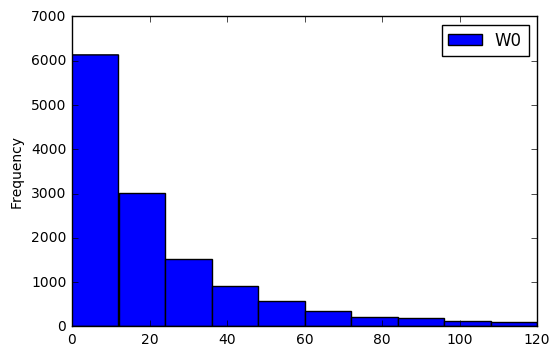

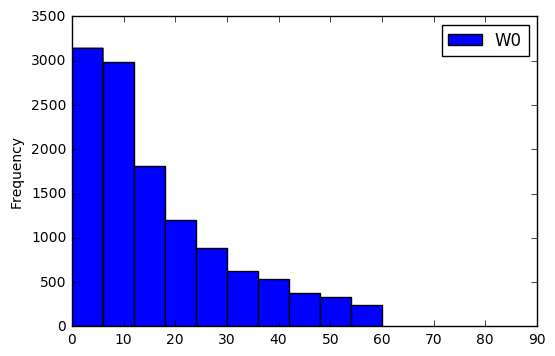

In [56]:
plt.show()

In [57]:
plt.close('all')

In [66]:
#fig=plt.figure()
#ax=fig.add_subplot(111)
plt.figure()
ax=plt.subplot()
#ax=plt.gca()

In [67]:
mu, sigma = 100, 15
x = mu + sigma * np.random.randn(10000)

In [68]:
counts, bins, patches = ax.hist(x, 50, normed=1, facecolor='green', alpha=0.75)

In [69]:
import matplotlib.mlab as mlab
# hist uses np.histogram under the hood to create 'n' and 'bins'.
# np.histogram returns the bin edges, so there will be 50 probability
# density values in n, 51 bin edges in bins and 50 patches.  To get
# everything lined up, we'll compute the bin centers
bincenters = 0.5*(bins[1:]+bins[:-1])
# add a 'best fit' line for the normal PDF
#y = mlab.normpdf( bincenters, mu, sigma)
#l = ax.plot(bincenters, y, 'r--', linewidth=1)
#print(l)

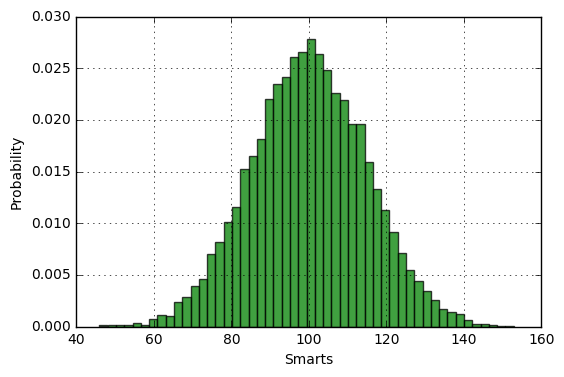

In [70]:
ax.set_xlabel('Smarts')
ax.set_ylabel('Probability')
#ax.set_title(r'$\mathrm{Histogram\ of\ IQ:}\ \mu=100,\ \sigma=15$')
ax.set_xlim(40, 160)
ax.set_ylim(0, 0.03)
ax.grid(True)

plt.show()

In [63]:
print(counts)

[  4.26518859e-05   4.26518859e-05   1.27955658e-04   1.70607544e-04
   1.27955658e-04   1.27955658e-04   4.69170745e-04   6.39778289e-04
   1.06629715e-03   9.80993377e-04   1.87668298e-03   2.98563202e-03
   4.17988482e-03   5.24618197e-03   7.08021307e-03   8.40242153e-03
   1.09615347e-02   1.16013130e-02   1.46295969e-02   1.87668298e-02
   1.99610826e-02   2.28614109e-02   2.50366571e-02   2.67853844e-02
   2.55058278e-02   2.58470429e-02   2.83208523e-02   2.66147768e-02
   2.32879297e-02   1.99184307e-02   1.80843996e-02   1.44163375e-02
   1.31367809e-02   1.06629715e-02   9.80993377e-03   6.73899798e-03
   5.58739706e-03   3.83866974e-03   3.75336596e-03   2.30320184e-03
   1.27955658e-03   1.45016412e-03   8.95689605e-04   2.55911316e-04
   2.55911316e-04   1.70607544e-04   0.00000000e+00   1.27955658e-04
   4.26518859e-05   4.26518859e-05]


In [64]:
print(bins)

[  41.06151386   43.40607607   45.75063828   48.09520049   50.4397627
   52.78432491   55.12888712   57.47344933   59.81801154   62.16257375
   64.50713597   66.85169818   69.19626039   71.5408226    73.88538481
   76.22994702   78.57450923   80.91907144   83.26363365   85.60819586
   87.95275807   90.29732028   92.64188249   94.9864447    97.33100691
   99.67556912  102.02013133  104.36469354  106.70925575  109.05381796
  111.39838017  113.74294239  116.0875046   118.43206681  120.77662902
  123.12119123  125.46575344  127.81031565  130.15487786  132.49944007
  134.84400228  137.18856449  139.5331267   141.87768891  144.22225112
  146.56681333  148.91137554  151.25593775  153.60049996  155.94506217
  158.28962438]


In [65]:
print(patches)

<a list of 50 Patch objects>
